# ECG Signal Classification: Dataset Concepts + Implementation Guide

This notebook is designed to teach both the **concept** and the **code**.

What you will learn:
1. How the MIT-BIH ECG dataset is structured (`.dat`, `.hea`, `.atr`).
2. How to inspect one record and understand what each file contributes.
3. How annotations map waveform positions to heartbeat labels.
4. How to visualize ECG signals and annotation points.
5. How to create fixed-length labeled segments for model training.

Why this order matters:
- If you understand the dataset structure first, preprocessing and model design become intuitive.
- ECG modeling is mostly about transforming a long time-series into clean labeled windows.

## Step 1: Import libraries

What we do:
- Import tools for file handling, numerical operations, plotting, and ECG reading.

Why:
- `wfdb` reads PhysioNet ECG files correctly.
- `numpy` and `pandas` help with array/tabular processing.
- `matplotlib` is used to inspect waveform quality before modeling.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb
from collections import Counter
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')

## Step 2: Point to dataset folder and verify structure

Dataset structure concept:
- Each ECG record is identified by a base name like `100`, `101`, etc.
- For each base name, there are usually three linked files:
  - `.dat`: sampled ECG waveform values (signal)
  - `.hea`: metadata (sampling rate, channels, gains)
  - `.atr`: annotation events (heartbeat labels and sample positions)

Why verification is important:
- If one file type is missing, downstream loading can fail or labels can be misaligned.

In [21]:
dataset_dir = "data/mit-bih-arrhythmia-database/mit-bih-arrhythmia-database-1.0.0"

if not os.path.exists(dataset_dir):
    raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")

print("Dataset directory exists:", dataset_dir)

Dataset directory exists: data/mit-bih-arrhythmia-database/mit-bih-arrhythmia-database-1.0.0


In [22]:
records = sorted([f for f in os.listdir(dataset_dir) if f.endswith('.dat')])
record_paths = [os.path.join(dataset_dir, os.path.splitext(f)[0]) for f in records]

print("Total .dat records found:", len(record_paths))
print("First 5 record base paths:")
for p in record_paths[:5]:
    print(" -", p)

# Verify that matching .hea and .atr exist for each record
missing_pairs = []
for base in record_paths:
    if not (os.path.exists(base + '.hea') and os.path.exists(base + '.atr')):
        missing_pairs.append(base)

print("Records missing .hea or .atr:", len(missing_pairs))
if missing_pairs:
    print("Example missing record:", missing_pairs[0])

Total .dat records found: 48
First 5 record base paths:
 - data/mit-bih-arrhythmia-database/mit-bih-arrhythmia-database-1.0.0\100
 - data/mit-bih-arrhythmia-database/mit-bih-arrhythmia-database-1.0.0\101
 - data/mit-bih-arrhythmia-database/mit-bih-arrhythmia-database-1.0.0\102
 - data/mit-bih-arrhythmia-database/mit-bih-arrhythmia-database-1.0.0\103
 - data/mit-bih-arrhythmia-database/mit-bih-arrhythmia-database-1.0.0\104
Records missing .hea or .atr: 0


## Step 3: Understand one record from all three files

What we do now:
1. Read raw `.hea` text.
2. Read parsed header using `wfdb`.
3. Read annotations (`.atr`) with sample positions and symbols.
4. Read signal (`.dat`) through `wfdb.rdrecord`.

Why:
- This gives complete visibility before feature engineering.
- You can debug data quality and label consistency early.

In [23]:
def load_header(header_file):
    with open(header_file, 'r') as f:
        return f.read()

example_record = record_paths[0]
print('Example record base path:', example_record)
print('\nRaw .hea file contents:\n')
print(load_header(example_record + '.hea'))

Example record base path: data/mit-bih-arrhythmia-database/mit-bih-arrhythmia-database-1.0.0\100

Raw .hea file contents:

100 2 360 650000
100.dat 212 200 11 1024 995 -22131 0 MLII
100.dat 212 200 11 1024 1011 20052 0 V5
# 69 M 1085 1629 x1
# Aldomet, Inderal



In [24]:
header = wfdb.io.rdheader(example_record)
print('Record name:', header.record_name)
print('Signal names (channels):', header.sig_name)
print('Sampling frequency (Hz):', header.fs)
print('Number of channels:', header.n_sig)
print('Comments:', header.comments)

Record name: 100
Signal names (channels): ['MLII', 'V5']
Sampling frequency (Hz): 360
Number of channels: 2
Comments: ['69 M 1085 1629 x1', 'Aldomet, Inderal']


In [25]:
annotation = wfdb.rdann(example_record, 'atr')
print('Annotation record name:', annotation.record_name)
print('Annotation description:', annotation.description)
print('First 10 annotation sample indices:', annotation.sample[:10])
print('First 10 annotation symbols:', annotation.symbol[:10])
print('Total annotation points:', len(annotation.symbol))

print('\nTop 10 annotation symbols by count in this record:')
print(pd.Series(annotation.symbol).value_counts().head(10))

Annotation record name: 100
Annotation description: None
First 10 annotation sample indices: [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']
Total annotation points: 2274

Top 10 annotation symbols by count in this record:
N    2239
A      33
+       1
V       1
Name: count, dtype: int64


## Step 4: Visualize signal and annotations

What to look for in plots:
- ECG waveform morphology (shape of QRS complexes and rhythm).
- Where annotation points fall on the timeline.
- Whether labels are aligned with visible heartbeat events.

Why this matters:
- Misalignment between signal and labels causes poor training no matter how good the model is.

Signal shape: (650000, 2)
Sampling frequency: 360
Record duration (seconds): 1805.56


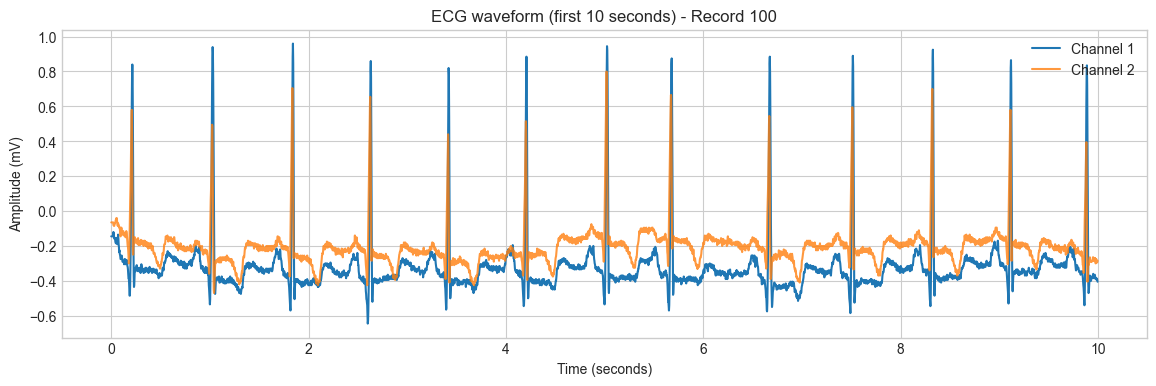

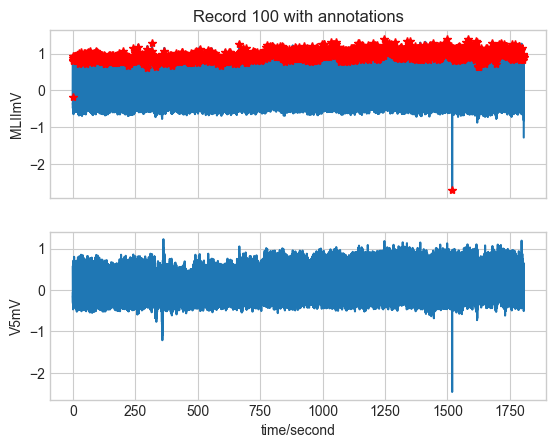

In [26]:
record = wfdb.rdrecord(example_record)
signal = record.p_signal
fs = record.fs

time = np.arange(signal.shape[0]) / fs

print('Signal shape:', signal.shape)
print('Sampling frequency:', fs)
print('Record duration (seconds):', round(len(time) / fs, 2))

# Plot first 10 seconds for readability
window_seconds = 10
window_samples = int(window_seconds * fs)

plt.figure(figsize=(14, 4))
plt.plot(time[:window_samples], signal[:window_samples, 0], label='Channel 1')
if signal.shape[1] > 1:
    plt.plot(time[:window_samples], signal[:window_samples, 1], label='Channel 2', alpha=0.8)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title(f'ECG waveform (first {window_seconds} seconds) - Record {record.record_name}')
plt.legend()
plt.show()

# Quick annotated plot using wfdb utility
wfdb.plot_wfdb(record=record, annotation=annotation, title=f'Record {record.record_name} with annotations')

## Step 5: Build labeled heartbeat segments

Concept:
- A full ECG record is long and contains many beats.
- We train a classifier on fixed-size windows centered around annotation points.
- Each window gets the annotation symbol at its center as label.

Why fixed windows:
- Neural models need consistent input shape.
- The model learns waveform patterns around a beat event.

In [27]:
def extract_labeled_segments(record_path, segment_length=360, ann_ext='atr'):
    rec = wfdb.rdrecord(record_path)
    ann = wfdb.rdann(record_path, ann_ext)

    segments = []
    labels = []

    for idx, sample_index in enumerate(ann.sample):
        start = sample_index - segment_length // 2
        end = sample_index + segment_length // 2

        if start >= 0 and end < len(rec.p_signal):
            # Use first two channels if available; duplicate first channel if only one exists
            if rec.p_signal.shape[1] >= 2:
                seg = rec.p_signal[start:end, :2]
            else:
                seg = np.tile(rec.p_signal[start:end, :1], (1, 2))

            if seg.shape[0] == segment_length:
                segments.append(seg)
                labels.append(ann.symbol[idx])

    return np.array(segments), np.array(labels)

segments, labels = extract_labeled_segments(example_record, segment_length=360)
print('Extracted segments shape:', segments.shape)
print('Extracted labels shape:', labels.shape)
print('Label distribution (top 10):')
print(pd.Series(labels).value_counts().head(10))

Extracted segments shape: (2271, 360, 2)
Extracted labels shape: (2271,)
Label distribution (top 10):
N    2237
A      33
V       1
Name: count, dtype: int64


## Step 6: Optional label grouping (fine-grained to broad classes)

Why group labels:
- MIT-BIH has many annotation symbols.
- Grouping reduces class complexity for a first model.
- You can later switch back to fine-grained multi-class classification for advanced work.

In [28]:
label_mapping = {
    'N': 'Normal',
    'A': 'Abnormal', 'V': 'Abnormal', 'L': 'Abnormal', 'R': 'Abnormal',
    'E': 'Abnormal', 'F': 'Abnormal', 'J': 'Abnormal', 'a': 'Abnormal', 'S': 'Abnormal',
    '~': 'Artifact', '|': 'Artifact', '/': 'Artifact', 'x': 'Artifact',
    '+': 'Artifact', '[': 'Artifact', '!': 'Artifact', ']': 'Artifact', '"': 'Artifact', 'Q': 'Artifact',
    'f': 'Fusion',
    'e': 'Escape', 'j': 'Escape'
}

grouped_labels = np.array([label_mapping.get(lbl, 'Other') for lbl in labels])
print(pd.Series(grouped_labels).value_counts())

Normal      2237
Abnormal      34
Name: count, dtype: int64


## Step 7: Prepare model-ready arrays and split data

What this does:
- Converts labels to integer class IDs.
- Keeps feature tensor in shape `(samples, 360, 2)`.
- Splits data into training and testing sets.

Why this is needed:
- Models require numeric targets and fixed-size inputs.
- Train/test split estimates generalization on unseen ECG segments.

In [29]:
# Use grouped labels; remove 'Other' for cleaner demo dataset
mask = grouped_labels != 'Other'
X = segments[mask]
y_text = grouped_labels[mask]

class_names = sorted(np.unique(y_text))
class_to_idx = {name: i for i, name in enumerate(class_names)}
y = np.array([class_to_idx[c] for c in y_text])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Class mapping:', class_to_idx)
print('X shape:', X.shape)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train label distribution:', Counter(y_train))
print('Test label distribution:', Counter(y_test))

Class mapping: {np.str_('Abnormal'): 0, np.str_('Normal'): 1}
X shape: (2271, 360, 2)
Train shape: (1816, 360, 2) Test shape: (455, 360, 2)
Train label distribution: Counter({np.int64(1): 1789, np.int64(0): 27})
Test label distribution: Counter({np.int64(1): 448, np.int64(0): 7})


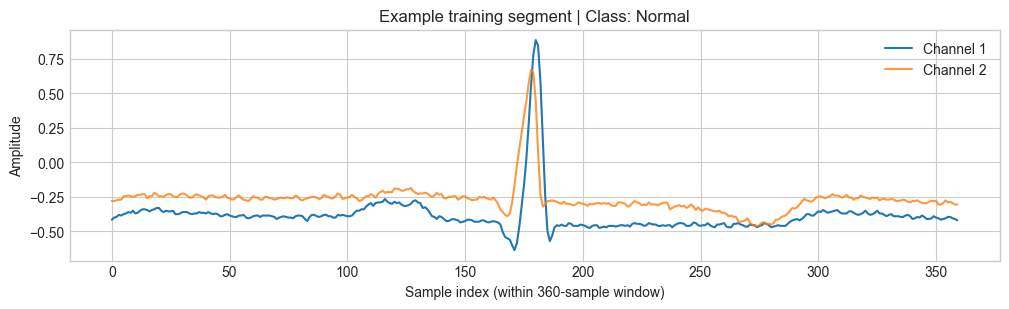

In [30]:
# Visual check: plot one training segment with its class
sample_i = 0
sample_seg = X_train[sample_i]
sample_label = class_names[y_train[sample_i]]

plt.figure(figsize=(12, 3))
plt.plot(sample_seg[:, 0], label='Channel 1')
if sample_seg.shape[1] > 1:
    plt.plot(sample_seg[:, 1], label='Channel 2', alpha=0.8)
plt.title(f'Example training segment | Class: {sample_label}')
plt.xlabel('Sample index (within 360-sample window)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Step 8: Train a baseline PyTorch 1D-CNN

Goal:
- Build a simple but strong baseline model on top of `X_train`, `y_train`, `X_test`, and `y_test`.

Why PyTorch here:
- You get explicit control over data loading, training loop, and evaluation.
- It is easier to debug each step compared to high-level training APIs.

Model idea:
- Use `Conv1D` layers to capture local ECG morphology (QRS-like patterns).
- Use global average pooling to summarize each feature map.
- Use a final linear layer for class prediction.

In [31]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [32]:

# Convert numpy arrays to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [33]:

# Build train/validation split from train set
full_train_dataset = TensorDataset(X_train_t, y_train_t)

In [34]:
val_ratio = 0.2
val_size = int(len(full_train_dataset) * val_ratio)
train_size = len(full_train_dataset) - val_size

In [35]:

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)
test_dataset = TensorDataset(X_test_t, y_test_t)

In [36]:

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 1453 | Val: 363 | Test: 455


In [37]:
class ECGConvNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=11, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Conv1d(64, 128, kernel_size=7, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Conv1d(128, 256, kernel_size=5, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        # Input shape: (batch, 360, 2) -> Conv1d expects (batch, channels, length)
        x = x.permute(0, 2, 1)
        x = self.features(x)
        x = x.mean(dim=2)  # Global average pooling over time dimension
        return self.classifier(x)

num_classes = len(class_names)
model = ECGConvNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

ECGConvNet(
  (features): Sequential(
    (0): Conv1d(2, 64, kernel_size=(11,), stride=(1,), padding=same)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=same)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=same)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
  )
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)


In [38]:
def run_epoch(model, loader, criterion, optimizer=None, desc='Train'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress = tqdm(loader, desc=desc, leave=False)

    with torch.set_grad_enabled(is_train):
        for xb, yb in progress:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_samples += xb.size(0)

            running_loss = total_loss / total_samples
            running_acc = total_correct / total_samples
            progress.set_postfix(loss=f'{running_loss:.4f}', acc=f'{running_acc:.4f}')

    return total_loss / total_samples, total_correct / total_samples

num_epochs = 20
patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_path = 'best_ecg_baseline_pytorch.pth'

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

epoch_bar = tqdm(range(1, num_epochs + 1), desc='Epochs')
for epoch in epoch_bar:
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, desc=f'Train E{epoch:02d}')
    val_loss, val_acc = run_epoch(model, val_loader, criterion, desc=f'Val   E{epoch:02d}')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    epoch_bar.set_postfix(
        train_loss=f'{train_loss:.4f}',
        train_acc=f'{train_acc:.4f}',
        val_loss=f'{val_loss:.4f}',
        val_acc=f'{val_acc:.4f}'
    )

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print('Early stopping triggered.')
            break

model.load_state_dict(torch.load(best_path, map_location=device))
print('Loaded best model from:', best_path)

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Train E01:   0%|          | 0/23 [00:00<?, ?it/s]

Val   E01:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=0.1471, train_acc=0.9828 | val_loss=0.0740, val_acc=0.9917


Train E02:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 06/20 | train_loss=0.0757, train_acc=0.9835 | val_loss=0.0589, val_acc=0.9890


Train E07:   0%|          | 0/23 [00:00<?, ?it/s]

Val   E07:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 07/20 | train_loss=0.0754, train_acc=0.9835 | val_loss=0.0564, val_acc=0.9890
Early stopping triggered.
Loaded best model from: best_ecg_baseline_pytorch.pth


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19284\2136983937.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=d

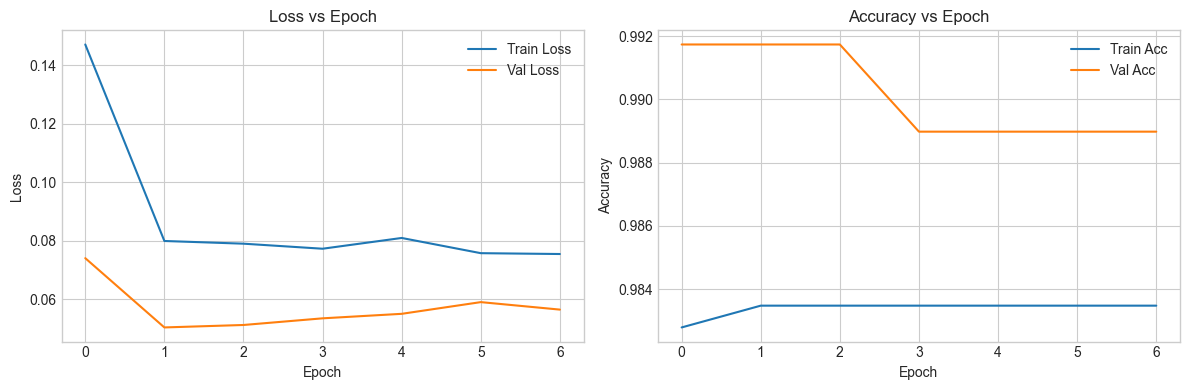

In [39]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Testing:   0%|          | 0/8 [00:00<?, ?it/s]

Test Loss: 0.0779
Test Accuracy: 0.9846


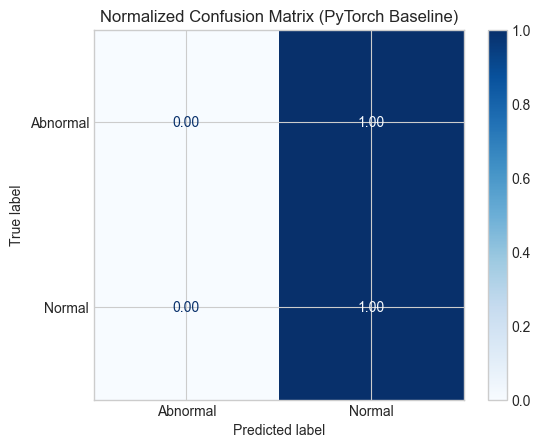

              precision    recall  f1-score   support

    Abnormal       0.00      0.00      0.00         7
      Normal       0.98      1.00      0.99       448

    accuracy                           0.98       455
   macro avg       0.49      0.50      0.50       455
weighted avg       0.97      0.98      0.98       455



c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [40]:
# Final test evaluation
model.eval()
total_loss = 0.0
total_correct = 0
total_samples = 0
all_true = []
all_pred = []

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc='Testing', leave=False):
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb).sum().item()
        total_samples += xb.size(0)

        all_true.extend(yb.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

test_loss = total_loss / total_samples
test_acc = total_correct / total_samples

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

cm = confusion_matrix(all_true, all_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('Normalized Confusion Matrix (PyTorch Baseline)')
plt.show()

print(classification_report(all_true, all_pred, target_names=class_names))

## Step 9: How to interpret results

Use this checklist after training:
1. If train accuracy is high but validation accuracy is much lower, overfitting is likely.
2. If confusion matrix has weak diagonal for minority classes, class imbalance is still affecting performance.
3. If all classes are poor, revisit preprocessing quality and segment extraction alignment.

Practical improvements:
- Try lower learning rate (`1e-4`) if training is unstable.
- Add class-weighted loss if minority classes remain weak.
- Train on segments extracted from all records (not only one record) for realistic performance.